# COGS 108 - The Link Between Population Density and Traffic Accidents in New York

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Aung Kyaw Myo
- Daniel Hwang
- Nicki Kwong

# Abstract

An average American spends 6% of their waking hours in the car and our group members spend even more because we love travelling. We wanted to know more about something we do everything: driving. Everyone who has driven in New York can confirm how stress it is driving there compared to here in San Diego. Our team things this is due to the population density and how crowded New York is.

For this project, we started by cleaning the data so every row have data and then picked the necessary variables to answer our research question. We then, grouped the variables by the neighbourhoods and added the number of injured and killed. After doing so, we had to add population count and land area for every neighborhood in order to find out the population density for each neighborhood. Finally we found out off the five boroughs in New York, boroughs with higher population density experience a higher rate of traffic accidents (per traffic volume) than boroughs with lower population density in 2024 until the population density exceeds 50,000.  Our explanation is that there has to be a limit to the positive correlation between total collisions and population density. At a certain threshold, it becomes a major priority for the government to implement safer driving conditions and improve people's driving ability to lower the amount of collisions.

# Research Question

Of the five boroughs in New York, do the boroughs with higher population density experience a higher rate of traffic accidents (per traffic volume) than boroughs with lower population density in 2024? 




## Background and Prior Work


 Traffic accidents are a major concern for urban planners and public safety experts, as their frequency and severity vary significantly across different neighborhoods. Various factors affect accident rates, including population density, road infrastructure, traffic regulations, and urban design. Proper understanding of these factors and existing data can help to identify possible solutions to improve road safety and reduce the rate of accidents.

One of the most influential factors is population density. Higher-density areas often experience higher levels of traffic, increasing the likelihood of collisions. However, density alone does not always lead to higher accident rates. Research suggests that urban planning plays a crucial role as a study examining Latin American cities found that cities with more compact development and rapid transit systems had lower mortality rates compared to cities with lower density development and without public transportation. This indicates that efficient transportation options and infrastructure can mitigate the risks associated with dense urban environments.

Road infrastructure also significantly affects accident rates. Poorly maintained roads, frequent construction and potholes all contribute to hazardous driving conditions. Using proper signage, maintaining roads, and designated pedestrian areas can help in reducing the rate of accidents. Cities with strong investments in infrastructure often experience fewer traffic fatalities compared to those with neglected road conditions.

Another key factor is traffic regulations and enforcement. The presence of traffic control devices and the active enforcement of existing traffic laws can lower accident rates. Some cities have successfully reduced accidents by implementing measures such as narrower streets, speed bumps, and pedestrian zones. Additionally, strict enforcement of traffic laws, including penalties for speeding and reckless driving, has been shown to improve road safety.



In [69]:
from IPython.core.display import display, HTML

# Display a clickable hyperlink in Jupyter Notebook
display(HTML('<a href="https://www.countyhealthrankings.org/strategies-and-solutions/what-works-for-health/strategies/traffic-calming" target="_blank">Traffic Calming</a>'))
display(HTML('<a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC8850369/" target="_blank">Urban Landscape Factors</a>'))

/var/folders/_s/38xyhsr15rbc3sgv316xfq200000gn/T/ipykernel_32749/780646014.py:1: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display



# Hypothesis



Hypothesis: Of the five boroughs in New York, the boroughs with higher population density experience a higher rate of traffic accidents (per traffic volume) compared to boroughs with lower population density within a year.

Explanation: We believe that factors such as increased pedestrian activity, increased number of vehicles (including bicycles), more congested, and complex infrastructure need more maintenance due to the increased amount of uses compared to lower population density boroughs.


# Data

## Data overview

- Dataset #1
  - Dataset Name: Motor_Vehicle_Collisions_-_Crashes
  - Link to the dataset: https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD
  - Number of observations: 31436 (after our data cleaning process)
  - Number of variables: 7 (after our data cleaning process)
  Variables after data cleaning: 
    - Crash date [timestamp]
    - Crash time [timestamp]
    - borough [categorical]
    - number_of_persons_injured [integer]
    - number_of_persons_killed [integer]
    - contributing_factor_vehicle_1 [categorical]
    - collision_id [unique integer]

Each row in the dataset represents a single crash with information about the crash recorded by law enforcement or reported data in New York. We've decided to narrow down the huge dataset of crashes by focusing on the year 2024 and removing any row with missing data. Out of 30 different variables, we chose this seven because the others are either repetitive (latitude, longtitude), unnecessary (ON STREET NAME,CROSS STREET NAME,OFF STREET NAME), or too specific (NUMBER OF PEDESTRIANS, MOTORCYCLIST, CYCLIST INJURED/KILLED). Of course, we've carefully analyized that our variable number_of_persons_injured includes all the injured parties (motorcyclist, pedestrians, cyclists, people in the cars) and same for the killed.

## Dataset: Motor Vehicle Collisions

In [12]:
import pandas as pd
# The file is too large to be uploaded to github, so I will use a subset of the data 
# The file is already sorted by date and will include all the data from 2024 if the first 50,000 rows are used.
file_path = "/Users/kevin/Downloads/Sorted_Motor_Vehicle_Collisions_-_Crashes.csv"
#data_url = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(file_path)
df_subset = df.head(50000)

df_subset.to_csv("filtered_crashes.csv", index=False)
print(df_subset.head())
print(df_subset.shape)

   CRASH DATE CRASH TIME   BOROUGH  ZIP CODE  LATITUDE  LONGITUDE  \
0    1/7/2025       2:39       NaN       NaN       NaN        NaN   
1  12/30/2024      11:45       NaN       NaN       NaN        NaN   
2  12/29/2024       1:29  BROOKLYN   11230.0  40.62179 -73.970024   
3  12/29/2024       6:55       NaN       NaN       NaN        NaN   
4  12/29/2024      13:21       NaN       NaN       NaN        NaN   

                 LOCATION           ON STREET NAME CROSS STREET NAME  \
0                     NaN    WHITESTONE EXPRESSWAY         20 AVENUE   
1                     NaN  QUEENSBORO BRIDGE UPPER               NaN   
2  (40.62179, -73.970024)            OCEAN PARKWAY          AVENUE K   
3                     NaN       THROGS NECK BRIDGE               NaN   
4                     NaN          BROOKLYN BRIDGE               NaN   

  OFF STREET NAME  ...  CONTRIBUTING FACTOR VEHICLE 2  \
0             NaN  ...                    Unspecified   
1             NaN  ...                

In [14]:
df = pd.read_csv('filtered_crashes.csv')

# Ensure column names are formatted correctly
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# Check column names
print("Columns in dataset:", df.columns.tolist())

# Convert crash_date
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')

# Check if conversion worked
print(df['crash_date'].head())
print("NaT values in crash_date:", df['crash_date'].isna().sum())

# Filter for 2024
df_2024 = df[df['crash_date'].dt.year == 2024]
df_2024.reset_index(drop=True, inplace=True)

# Check if filtering worked
print("Unique years in dataset:", df['crash_date'].dt.year.unique())
print("Rows in 2021 dataset:", df_2024.shape[0])

# Final output
column_list = df_2024.columns.tolist()
print("Columns after filtering:", column_list)
print(df_2024.head())
print(df_2024.shape)

Columns in dataset: ['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'cross_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3', 'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5', 'collision_id', 'vehicle_type_code_1', 'vehicle_type_code_2', 'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5']
0   2025-01-07
1   2024-12-30
2   2024-12-29
3   2024-12-29
4   2024-12-29
Name: crash_date, dtype: datetime64[ns]
NaT values in crash_date: 0
Unique years in dataset: [2025 2024 2023]
Rows in 2021 dataset: 48318
Columns after filtering: ['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude

In [15]:
selected_columns = [
    'crash_date', 'crash_time', 'borough',
    'number_of_persons_injured', 'number_of_persons_killed',
    'contributing_factor_vehicle_1', 'collision_id'
]

# Select only the desired columns
df_filtered = df_2024[selected_columns]

df_clean = df_filtered.dropna()

# Reset index after dropping missing values
df_clean.reset_index(drop=True, inplace=True)

print(df_clean.head())
print("Cleaned data shape:", df_clean.shape)

  crash_date crash_time    borough  number_of_persons_injured  \
0 2024-12-29       1:29   BROOKLYN                        1.0   
1 2024-12-29       9:35   BROOKLYN                        0.0   
2 2024-12-29       8:17      BRONX                        2.0   
3 2024-12-29      21:10   BROOKLYN                        0.0   
4 2024-12-29      14:58  MANHATTAN                        0.0   

   number_of_persons_killed contributing_factor_vehicle_1  collision_id  
0                       0.0                   Unspecified       4675373  
1                       0.0                   Unspecified       4456314  
2                       0.0                   Unspecified       4486660  
3                       0.0           Driver Inexperience       4487074  
4                       0.0           Passing Too Closely       4486519  
Cleaned data shape: (31436, 7)


# Results

## Exploratory Data Analysis

In order to answer our reasearch question, we had to find out the population density of each borough in New York. Below is the reference links of where we got our population and land area numbers.

In [16]:
from IPython.core.display import display, HTML

# Display a clickable hyperlink in Jupyter Notebook
display(HTML('<a href="https://www.worldatlas.com/articles/the-boroughs-of-new-york-city.html" target="_blank">Land Area - World Atlas</a>'))
display(HTML('<a href="https://metropolismoving.com/blog/new-york-city-population-in-2024/" target="_blank">Population - metropolismoving</a>'))

/var/folders/_s/38xyhsr15rbc3sgv316xfq200000gn/T/ipykernel_1987/1209488792.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


## Crash Analysis Based on Boroughs

We grouped the dataset by 5 boroughs, Bronx, Brooklyn, Manhattan, Queens, and Staten Island, and added up the number of injured, and killed, and got the names of collisions by counting collisions. Then, we added the number of injured and killed people into the data frame we are using to create visualizations. The graph below is helpful for the viewers to visualize the number of accidents occurring in each borough and the proportion of injuries and deaths to collisions. According to the graph, there seems to be a large range in total collisions among the five boroughs. Brooklyn is the highest, with 10980 total collisions, and Staten Island is the lowest, with 1171 total collisions. However the injured and killed proportion is about the same in each borough, ranging from 0.40 to 0.48. 

         borough  number_of_persons_injured  number_of_persons_killed  \
0          BRONX                     2480.0                      19.0   
1       BROOKLYN                     5148.0                      20.0   
2      MANHATTAN                     2008.0                      15.0   
3         QUEENS                     3704.0                      16.0   
4  STATEN ISLAND                      556.0                       2.0   

   collision_id  
0          5783  
1         10980  
2          5084  
3          8418  
4          1171  


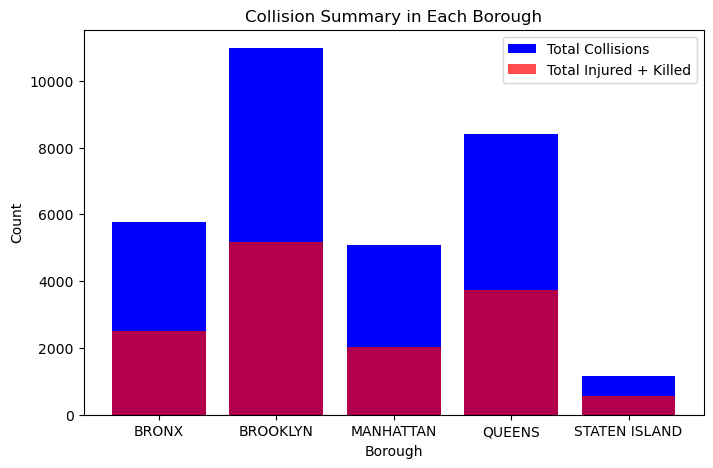

In [17]:
borough_grouped = df_clean.groupby('borough').agg({
    'number_of_persons_injured': 'sum',
    'number_of_persons_killed': 'sum',
    'collision_id': 'count'  # Count of incidents per borough
}).reset_index()
print(borough_grouped)

borough_grouped.rename(columns={'collision_id': 'total_collisions'}, inplace=True)

# Create a new column: Total Injured + Killed
borough_grouped["total_injured_killed"] = borough_grouped["number_of_persons_injured"] + borough_grouped["number_of_persons_killed"]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.bar(borough_grouped["borough"], borough_grouped["total_collisions"], color='blue', label="Total Collisions")
plt.bar(borough_grouped["borough"], borough_grouped["total_injured_killed"], color='red', label="Total Injured + Killed", alpha=0.7)
plt.xlabel("Borough")
plt.ylabel("Count")
plt.title("Collision Summary in Each Borough")
plt.legend()
plt.show()

## Distribution of Collisions and Population Density per Borough

In [18]:
borough_grouped["injured_killed_proportion"] = (
    (borough_grouped["number_of_persons_injured"] + borough_grouped["number_of_persons_killed"])
    / borough_grouped["total_collisions"]
)

# Statistics from metropolismoving
borough_grouped = borough_grouped.assign(population = [1297660, 2679620, 1645867, 2177805, 492925])

# Statistics from World Atlas in square miles
borough_grouped = borough_grouped.assign(land_area = [42.4, 71, 22.8, 109.7, 58.69])

borough_grouped["pop_density"] = borough_grouped["population"] / borough_grouped["land_area"]
print(borough_grouped)

         borough  number_of_persons_injured  number_of_persons_killed  \
0          BRONX                     2480.0                      19.0   
1       BROOKLYN                     5148.0                      20.0   
2      MANHATTAN                     2008.0                      15.0   
3         QUEENS                     3704.0                      16.0   
4  STATEN ISLAND                      556.0                       2.0   

   total_collisions  total_injured_killed  injured_killed_proportion  \
0              5783                2499.0                   0.432129   
1             10980                5168.0                   0.470674   
2              5084                2023.0                   0.397915   
3              8418                3720.0                   0.441910   
4              1171                 558.0                   0.476516   

   population  land_area   pop_density  
0     1297660      42.40  30605.188679  
1     2679620      71.00  37741.126761  
2    

Below is a histogram for the Distribution of Collisions per Borough and a histogram for the distribution of Population Density per Borough to help us better visualize the key variables that we will be using and their distributions. The first shows that Brooklyn has the highest number of collisions, followed by Queens, the Bronx, and Manhattan. Staten Island has the lowest frequency of collisions, indicating that the majority of collisions are concentrated in the larger boroughs. From the second graph, we can see how densely populated each borough is. Manhattan stands out as the borough with the highest population density of 72187.15. The other boroughs would be clustered together, ranging from 8398.79 in Staten Island, to 37741.13 in Brooklyn, indicating less crowding compared to Manhattan.

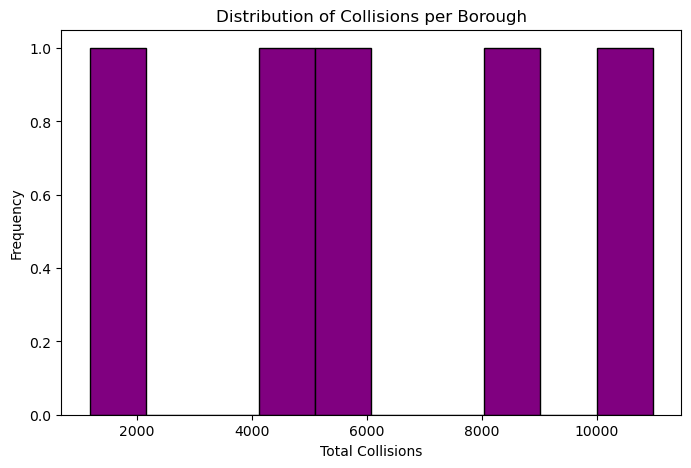

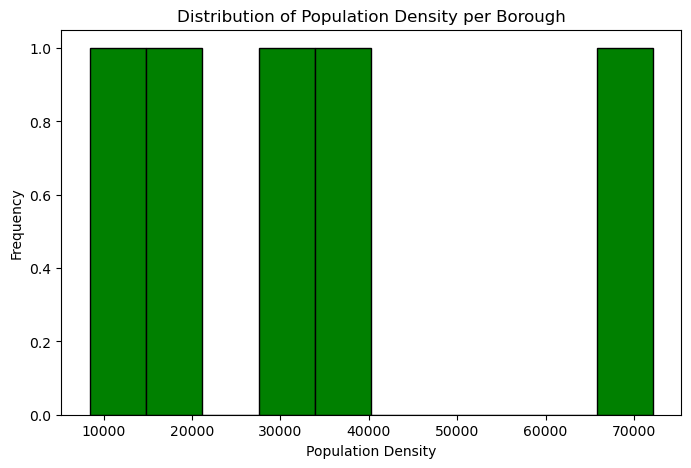

In [19]:
# EDA: Distribution of Key Variables
# EDA: Histogram for Collision Distribution
plt.figure(figsize=(8,5))
plt.hist(borough_grouped["total_collisions"], bins=10, color='purple', edgecolor='black')
plt.xlabel("Total Collisions")
plt.ylabel("Frequency")
plt.title("Distribution of Collisions per Borough")
plt.show()

# EDA: Histogram for Population Density Distribution
plt.figure(figsize=(8,5))
plt.hist(borough_grouped["pop_density"], bins=10, color='green', edgecolor='black')
plt.xlabel("Population Density")
plt.ylabel("Frequency")
plt.title("Distribution of Population Density per Borough")
plt.show()


## Outliers in Collision

The graph below represents the distribution of total collision counts, which shows potential outliers in the collision data. The distribution appears to be relatively symmetrical, with no extreme outliers, meaning that all observed values fall within the expected range. However, the interquartile range (IQR) is slightly wide, suggesting a significant spread in collision counts across different observations. The upper whisker also extends further than the lower whisker, possibly indicating a right-skewed distribution.

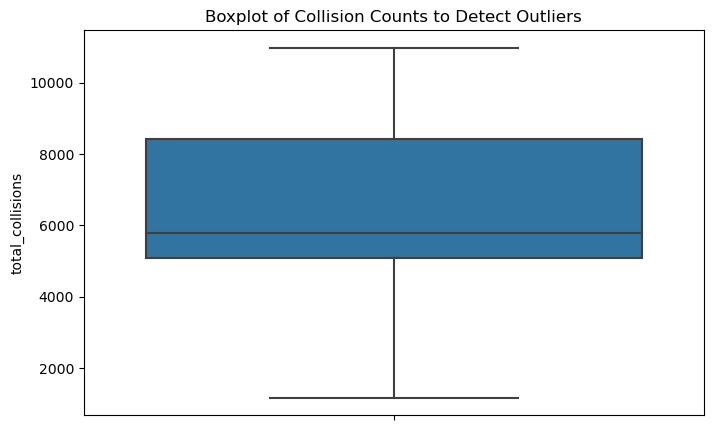

In [20]:
# EDA: Boxplot for Outliers in Collision Data

plt.figure(figsize=(8,5))
sns.boxplot(data=borough_grouped, y="total_collisions")
plt.title("Boxplot of Collision Counts to Detect Outliers")
plt.show()

## Relationship Between Population Density and Collisions

Below is the main graph that best summarizes and answers our question. Of the five boroughs in New York, boroughs with higher population density experience a higher rate of traffic accidents (per traffic volume) than boroughs with lower population density in 2024 until the population density exceeds 50,000. To our surprise, Manhattan with the highest population density (~72187.15) out of all 5 bouroughs has the second least collisions (5084). Our explanation is that there has to be a limit to the positive correlation between total collisions and population density. At a certain threshold, it becomes a major priority for the government to implement safer driving conditions and improve people's driving ability to lower the amount of collisions. 


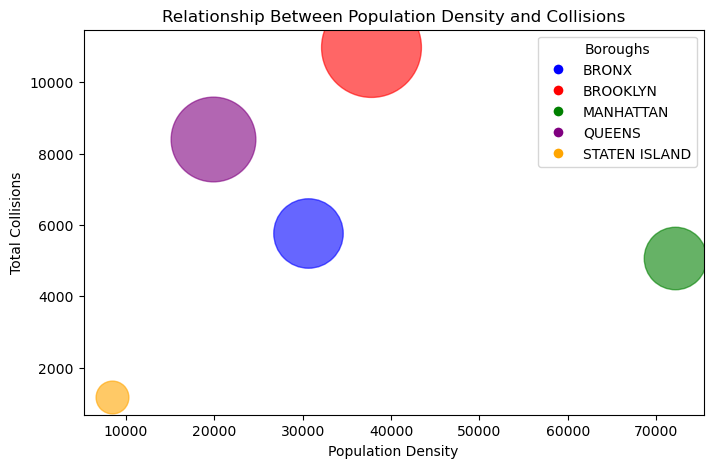

In [21]:
# EDA: Scatter Plot for Relationship Between Population Density and Collisions

plt.figure(figsize=(8,5))
colors = {"BRONX": "blue", "BROOKLYN": "red", "MANHATTAN": "green", "QUEENS": "purple", "STATEN ISLAND": "orange"}
handles = []
for borough in borough_grouped["borough"].unique():
    subset = borough_grouped[borough_grouped["borough"] == borough]
    scatter = plt.scatter(subset["pop_density"], subset["total_collisions"], 
                          s=subset["total_injured_killed"], 
                          c=colors[borough], 
                          alpha=0.6, label=borough)
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[borough], markersize=8, label=borough))
plt.xlabel("Population Density")
plt.ylabel("Total Collisions")
plt.title("Relationship Between Population Density and Collisions")
plt.legend(handles=handles, title="Boroughs")
plt.show()



## Correlation Matrix

Below is the correlation matrix that represents the relationship between different variables related to collisions, injuries, fatalities, and demographic factors. The color scale ranges from -1 (strong negative correlation, blue) to 1 (strong positive correlation, red). The correlation matrix reveals strong relationships between collision-related variables and demographic factors. Total collisions show a nearly perfect correlation (1.0) with the number of persons injured and a strong correlation (0.84) with the number of persons killed, indicating that more collisions generally lead to more injuries and fatalities. Additionally, total collisions and population are highly correlated (0.98), suggesting that larger populations tend to experience more accidents. Similarly, total injured and total killed also have a strong correlation (0.81), reinforcing the link between the severity of collisions and population size. On the other hand, negative correlations highlight interesting trends, such as the injured/killed proportion and the number of persons killed (-0.37), implying that areas with more fatalities might have a lower proportion of injuries relative to deaths. Additionally, population density has a strong negative correlation with the injured/killed proportion (-0.79), suggesting that in densely populated areas, accidents may be more severe, leading to a higher fatality rate compared to injuries. Moderate correlations, such as land area and total collisions (0.45), indicate that larger geographic regions tend to have more collisions, whereas population density and total collisions (0.21) have a weaker relationship, suggesting that denser areas do not necessarily experience significantly more accidents. Overall, the correlation matrix shows that collision-related variables are highly correlated with population size, meaning larger populations typically experience more accidents, injuries, and fatalities. Meanwhile, population density has a mixed impact, with strong negative correlations with the proportion of injured-to-killed individuals. This suggests that in densely populated areas, accidents may be more severe, leading to a higher fatality rate compared to injuries.

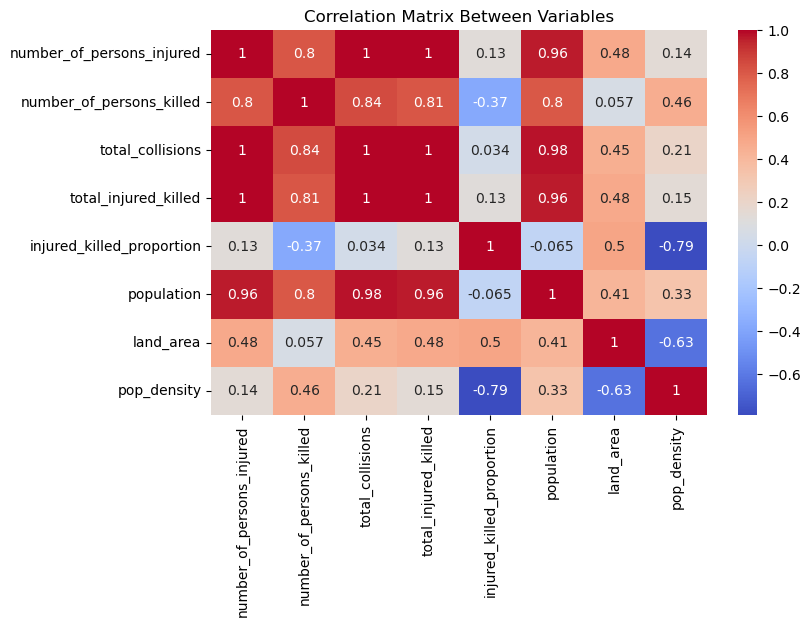

In [22]:
# EDA: Correlation Matrix

plt.figure(figsize=(8,5))
sns.heatmap(borough_grouped.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Between Variables")
plt.show()

## Linear Regression Analysis

We have performed a Linear Regression Analysis below. The results indicate that population density has a very weak and statistically insignificant relationship with total collisions. The model explains only 4.3% of the variation in total collisions, as indicated by the low R-squared value, and the adjusted R-squared is negative, suggesting that the model is not providing useful predictive power. The p-value for the F-statistic is 0.737, which is much higher than the typical 0.05 threshold, indicating that the overall model is not statistically significant. Additionally, the population density coefficient of 0.0317, although positive, has a high p-value of 0.737, further suggesting that population density does not significantly impact total collisions. Given the small sample size of just five observations, these results should be taken with caution, and further data would be needed to make more reliable conclusions.

In [23]:
import statsmodels.api as sm
import patsy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Linear Regression Analysis
# Create design matrices using Patsy
y, X = patsy.dmatrices("total_collisions ~ pop_density", data=borough_grouped, return_type="dataframe")

# Fit OLS Model
model = sm.OLS(y, X).fit()
print(model.summary())

# Split Data for Prediction
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)
print(f"R-squared Score: {r2}")


                            OLS Regression Results                            
Dep. Variable:       total_collisions   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                 -0.276
Method:                 Least Squares   F-statistic:                    0.1354
Date:                Tue, 18 Mar 2025   Prob (F-statistic):              0.737
Time:                        20:48:41   Log-Likelihood:                -47.492
No. Observations:                   5   AIC:                             98.98
Df Residuals:                       3   BIC:                             98.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    5216.9879   3454.189      1.510      

/Users/kevin/miniforge3/envs/dsc80/lib/python3.8/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/Users/kevin/miniforge3/envs/dsc80/lib/python3.8/site-packages/sklearn/metrics/_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


# Ethics & Privacy

The research and analysis on the distribution of accidents across different boroughs could potentially involve a plethora of ethical and privacy concerns. To ensure integrity, we will address any apparent biases and privacy issues.
First, we acknowledge potential bias in the datasets we gather. There is a possibility that accident reports can be collected disproportionately. To address these discrepancies we will take the following steps.
We will identify any demographic or geographic trends in the gathered data to see if there are any biases including both over and underrepresentation of any given communities or accident types. As for data collection and processing, we will implement the use of stratified random sampling and statistical weighting to properly interpret the data. To ensure and minimize bias, we will also cross-check our data with official government reports and findings.

Second, data privacy is a concern as data often may contain sensitive information that may possibly reveal information about certain people involved in some accidents. We will make sure that the data that we use is randomized and does not infringe on any personal copyrights. The analysis that we provide will fully be based on publicly available information, which ensures that we are not disregarding any regulations.

Our team will make certain that there is anonymity when showing data, using sources that are available for public use as well as removing any potential information that could inadvertently reveal someone’s identity. Steps will be taken in terms of cybersecurity so that no data leaks in our project with strict access controls and a secure method of accessing them.


# Discussion and Conclusion

Our study examined the correlation between population density and traffic accident rates across the five main neighborhoods of New York City in 2024. Our main goal was to determine if there was a correlation in boroughs with higher population density experiencing a greater proportion of traffic accidents compared to those with a lower density. Through our analysis, we considered various contributing factors, including pedestrian activity, vehicle congestion, infrastructure conditions, and traffic regulations. 

Our findings and numerous data indicate that boroughs with higher population density generally do experience a higher rate of traffic accidents per traffic volume, but this is not the main trend. If anything, it’s something closer to natural occurrence as higher population density means that much of an easier chance of accidents happening. Manhattan being the most populated actually had the second-lowest number of total collisions at 5,084. This data suggested that once population density exceeds a certain number, roughly around 50,000 people per square mile, the relationship between population density and accident rates actually weakens and follows an inverse trend. As a result, we hypothesized that at extreme levels of population density, traffic safety becomes a top priority for the city, leading to proper and stricter regulation of traffic laws, constant improvement and maintenance in the road infrastructure, overall creating much safer driving conditions. 

One limitation of our study is that we relied on publicly available traffic and population data, which may not capture other important variables such as driver behavior, law enforcement presence, and real-time road conditions. Additionally, our analysis does not account for temporary fluctuations such as weather, construction, or special events, which could influence accident rates. Future research could integrate these factors for a more detailed understanding of accident trends. 

Our findings are significant for both the current and the future of urban planning and traffic management. While cities with higher population densities require strong safety regulations and public transportation investments, lower-density cities will benefit from targeted improvements in road infrastructure and stricter enforcement of traffic laws. Our research suggests that effective policy interventions can mitigate the risks associated with population density, ultimately leading to safer road conditions across all boroughs. 

# Team Contributions

Aung Kyaw Myo:
- Wrote the abstract for the project
- Created the research question and the hypothesis, reviewed them with team members, and finalized them
- Created the initial data frames and data cleaning for Dataset #1
- Created the data frames and visualizations for Collision Summary, Distribution of Collisions per Borough, Distribution of Population density per Borough, Boxplot of Collision Counts to Detect Outliers, Relationship Between Population Density and Collisions, and the Correlation Matrix Between Variables
- Formed the Linear Regression Analysis

Daniel Hwang:
- Wrote Background and Prior Work for the research question
- Edited Ethics & Privacy and finalized it
- Wrote Discussion and Conclusion for the project

Nicki Kwong:
- Wrote descriptions for Collision Summary graph, Distribution of Collisions per Borough graph, Distribution of Population density per Borough graph, Boxplot of Collision Counts to Detect Outliers, Correlation Matrix Between Variables, and the Linear Regression Analysis
- Created Team Expectations, reviewed it with team members and finalized it
- Wrote Project Timeline Proposal, reviewed it with team members, and finalized it
- Edited video

